### Dataset and Data Gathering
- Dataset file: `hourly_data.csv`
- Topic: Assessment of Urban Heat Patterns in Philippine Cities and Their Implications for Public Health and Climate Resilience
- Source method: Kaggle

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.functions import col, when, avg, to_timestamp, hour, month, to_date, round as spark_round, max as spark_max, min as spark_min, sum as spark_sum, isnan
import matplotlib.pyplot as plt
from functools import reduce
import os
import re

spark = SparkSession.builder.appName("WeatherHeatIndexPreprocessing").getOrCreate()
os.makedirs("analysis_assets", exist_ok=True)

In [2]:
# StructType schema
schema = StructType([
    StructField("city_name", StringType(), True),
    StructField("datetime", StringType(), True),
    StructField("temperature_2m", DoubleType(), True),
    StructField("relative_humidity_2m", DoubleType(), True),
    StructField("dew_point_2m", DoubleType(), True),
    StructField("apparent_temperature", DoubleType(), True),
    StructField("precipitation", DoubleType(), True),
    StructField("rain", DoubleType(), True),
    StructField("snowfall", DoubleType(), True),
    StructField("snow_depth", DoubleType(), True),
    StructField("weather_code", DoubleType(), True),
    StructField("pressure_msl", DoubleType(), True),
    StructField("surface_pressure", DoubleType(), True),
    StructField("cloud_cover", DoubleType(), True),
    StructField("cloud_cover_low", DoubleType(), True),
    StructField("cloud_cover_mid", DoubleType(), True),
    StructField("cloud_cover_high", DoubleType(), True),
    StructField("et0_fao_evapotranspiration", DoubleType(), True),
    StructField("vapour_pressure_deficit", DoubleType(), True),
    StructField("wind_speed_10m", DoubleType(), True),
    StructField("wind_speed_100m", DoubleType(), True),
    StructField("wind_direction_10m", DoubleType(), True),
    StructField("wind_direction_100m", DoubleType(), True),
    StructField("wind_gusts_10m", DoubleType(), True),
    StructField("soil_temperature_0_to_7cm", DoubleType(), True),
    StructField("soil_temperature_7_to_28cm", DoubleType(), True),
    StructField("soil_temperature_28_to_100cm", DoubleType(), True),
    StructField("soil_temperature_100_to_255cm", DoubleType(), True),
    StructField("soil_moisture_0_to_7cm", DoubleType(), True),
    StructField("soil_moisture_7_to_28cm", DoubleType(), True),
    StructField("soil_moisture_28_to_100cm", DoubleType(), True),
    StructField("soil_moisture_100_to_255cm", DoubleType(), True),
    StructField("shortwave_radiation", DoubleType(), True),
    StructField("direct_radiation", DoubleType(), True),
    StructField("diffuse_radiation", DoubleType(), True),
    StructField("direct_normal_irradiance", DoubleType(), True),
    StructField("global_tilted_irradiance", DoubleType(), True),
    StructField("terrestrial_radiation", DoubleType(), True),
    StructField("shortwave_radiation_instant", DoubleType(), True),
    StructField("direct_radiation_instant", DoubleType(), True),
    StructField("diffuse_radiation_instant", DoubleType(), True),
    StructField("direct_normal_irradiance_instant", DoubleType(), True),
    StructField("global_tilted_irradiance_instant", DoubleType(), True),
    StructField("terrestrial_radiation_instant", DoubleType(), True)
])

raw_df = spark.read.csv("hourly_data.csv", header=True, schema=schema)
df = raw_df.cache()  # full dataset (about 1.5M rows)

print("Raw rows:", raw_df.count())
print("Rows used (full dataset):", df.count())
print("Columns:", len(df.columns))

Raw rows: 1499328
Rows used (full dataset): 1499328
Columns: 44


In [3]:
def eda_matplotlib(df, title, sample_n=50000):
    print(f"\n===== EDA CHECKPOINT: {title} =====")
    total_rows = df.count()
    print("Rows:", total_rows, "Columns:", len(df.columns))

    missing_conditions = []
    for c, t in df.dtypes:
        cond = col(c).isNull()
        if t in ("double", "float"):
            cond = cond | isnan(col(c))
        missing_conditions.append(cond)

    rows_with_missing = 0
    if missing_conditions:
        rows_with_missing = df.filter(reduce(lambda a, b: a | b, missing_conditions)).count()
    print("Rows with at least one missing value:", rows_with_missing)

    metrics = [c for c in ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m", "apparent_temperature"] if c in df.columns]
    if metrics:
        df.select(*metrics).describe().show()

    plot_cols = [c for c in ["temperature_2m", "relative_humidity_2m", "precipitation"] if c in df.columns]
    if len(plot_cols) < 2:
        return

    fraction = min(1.0, sample_n / max(1, total_rows))
    pdf = df.sample(False, fraction, 42).select(*plot_cols).dropna().toPandas()
    if pdf.empty:
        return

    fig, ax = plt.subplots(1, 3, figsize=(19, 5))
    ax[0].hist(pdf["temperature_2m"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
    ax[0].set_title(f"{title}: Temperature Distribution")
    ax[1].scatter(pdf["temperature_2m"], pdf["relative_humidity_2m"], s=8, alpha=0.3, color="darkorange")
    ax[1].set_title(f"{title}: Temp vs Humidity")
    ax[2].boxplot(pdf["precipitation"], vert=True)
    ax[2].set_title(f"{title}: Precipitation Boxplot")
    plt.tight_layout()

    safe = re.sub(r"[^a-zA-Z0-9]+", "_", title.strip().lower()).strip("_")
    path = os.path.join("analysis_assets", f"{safe}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved plot:", path)
    plt.show()


===== EDA CHECKPOINT: Step 1 - Raw Full Dataset =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 269000
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|  count|           1491930|             1491930|            1491930|          1491930|             1491930|
|   mean|26.996553524629128|   80.23429249361565|0.27922308687398834|9.304811217684621|  31.411685534844093|
| stddev|2.9356353591760356|  13.629631833769947| 1.0461154279108915|6.291523351602621|  3.6222541033782734|
|    min|               8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|              40.5|               100.0|               77.6|             72.3|                45.6|
+-

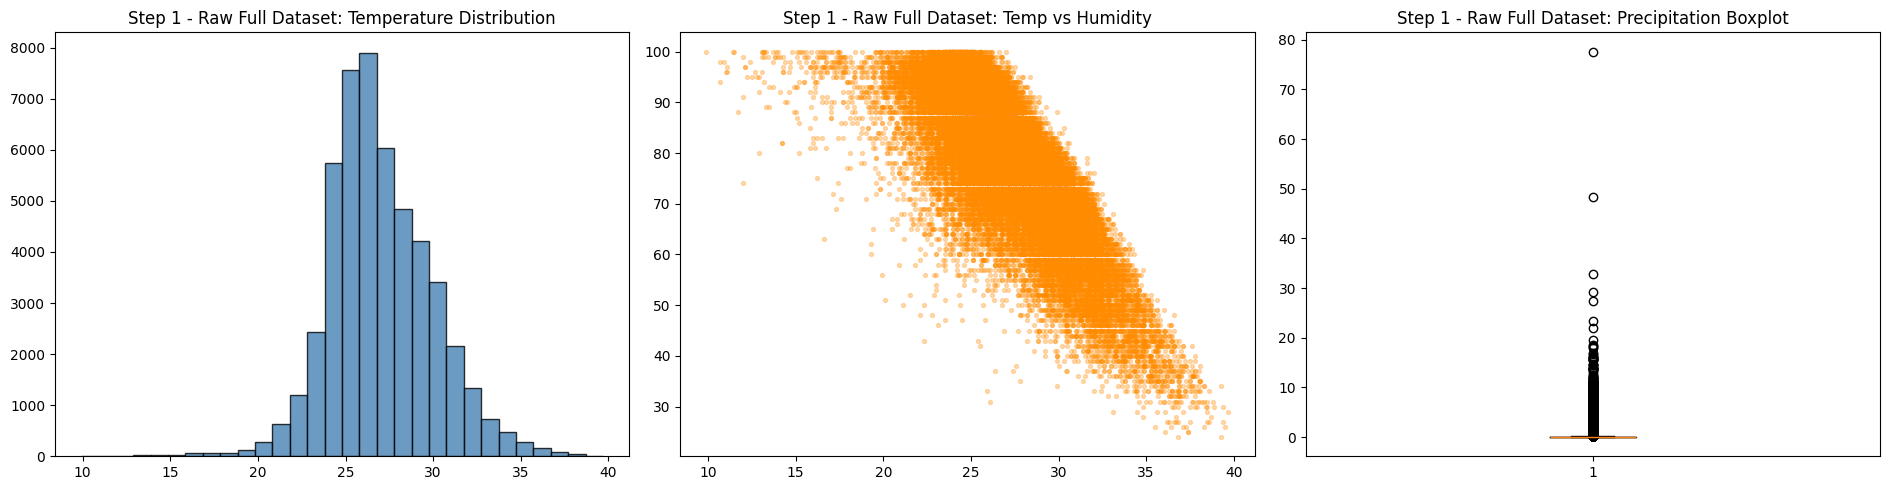

In [4]:
# Step 1: Raw full dataset
eda_matplotlib(df, "Step 1 - Raw Full Dataset")


===== EDA CHECKPOINT: Step 2 - After Fill Missing Values =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 0
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|  count|           1499328|             1499328|            1499328|          1499328|             1499328|
|   mean|26.996553524628702|   80.23429249361527|0.27922308687398434| 9.30481121768465|  31.411685534843787|
| stddev|2.9283838767474455|   13.59596449308952| 1.0435313577810397|6.275982296447151|  3.6133065643385573|
|    min|               8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|              40.5|               100.0|               77.6|             72.3|                45.6

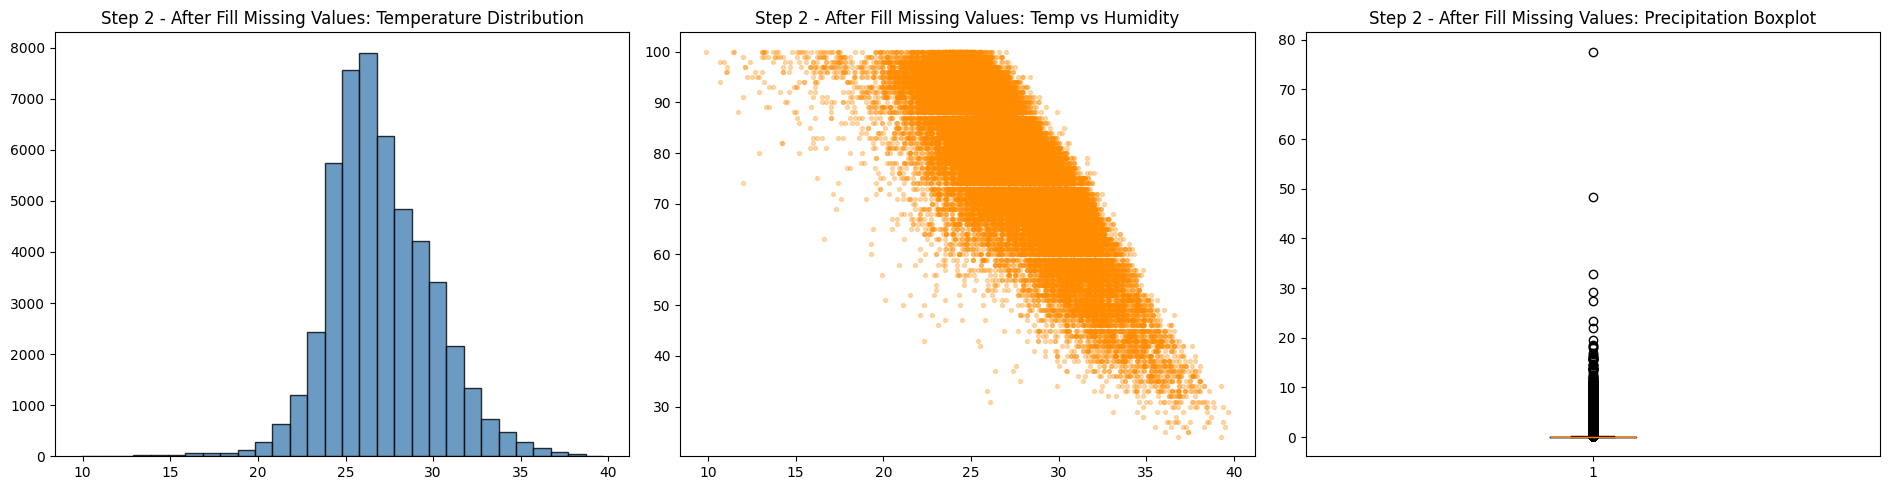

In [5]:
# Step 2: Fill missing values
numeric_cols = [c for c, t in df.dtypes if t in ("double", "int", "bigint", "float")]
means_row = df.select([avg(col(c)).alias(c) for c in numeric_cols]).collect()[0].asDict()
fill_map = {k: float(v) for k, v in means_row.items() if v is not None}
df_filled = df.fillna(fill_map).fillna({"city_name": "Unknown"})
eda_matplotlib(df_filled, "Step 2 - After Fill Missing Values")

Rows before deduplication: 1499328
Rows after key-based deduplication: 1499328

===== EDA CHECKPOINT: Step 3 - After Key-Based Deduplication =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 0
+-------+-----------------+--------------------+-------------------+-----------------+--------------------+
|summary|   temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+-----------------+--------------------+-------------------+-----------------+--------------------+
|  count|          1499328|             1499328|            1499328|          1499328|             1499328|
|   mean|26.99655352462917|   80.23429249361584|0.27922308687406155| 9.30481121768445|   31.41168553484416|
| stddev|2.928383876747435|   13.59596449308951| 1.0435313577810386|6.275982296447148|  3.6133065643385587|
|    min|              8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|             40.5|    

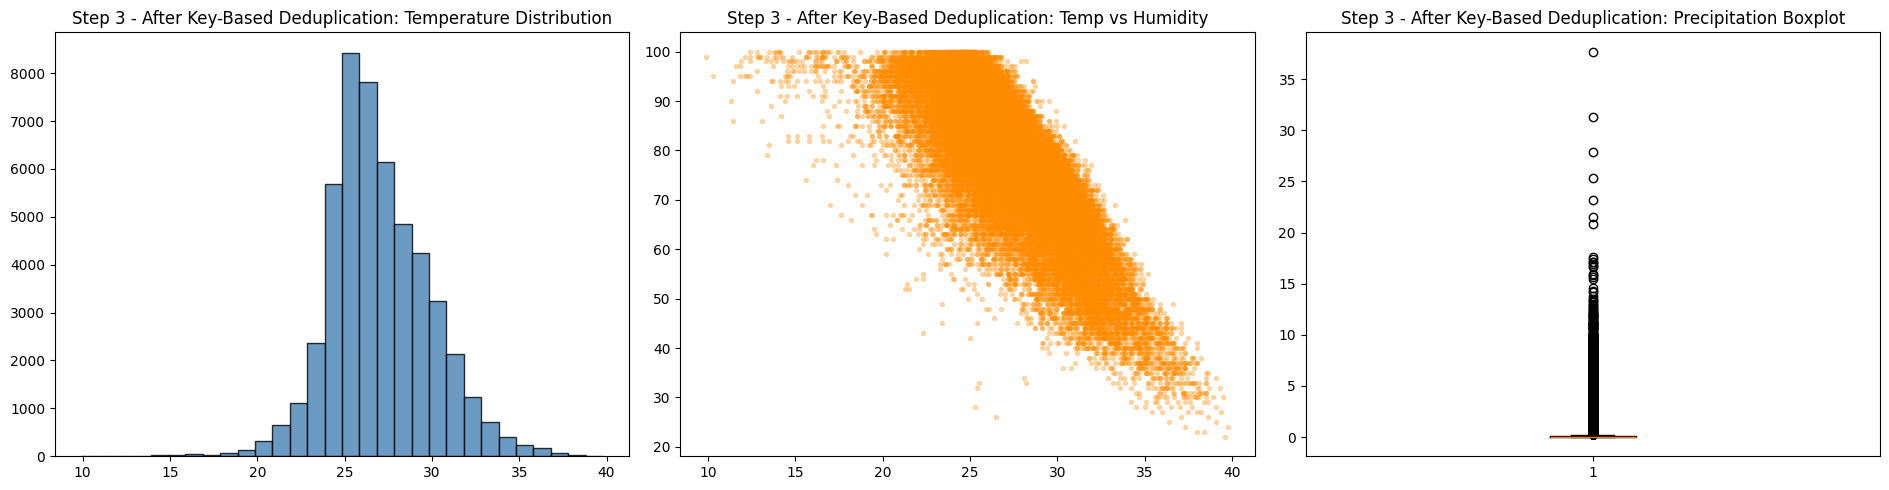

In [6]:
# Step 3: Deduplicate by record keys (city + datetime) - memory-safe for full dataset
from pyspark import StorageLevel

# Repartition by city to reduce shuffle pressure, then persist to disk (not RAM).
df_clean = (
    df_filled
    .dropna(subset=["city_name", "datetime"])
    .repartition(64, "city_name")
    .dropDuplicates(["city_name", "datetime"])
    .persist(StorageLevel.DISK_ONLY)
)

print("Rows before deduplication:", df_filled.count())
print("Rows after key-based deduplication:", df_clean.count())
eda_matplotlib(df_clean, "Step 3 - After Key-Based Deduplication")

Rows after filtering: 1499309

===== EDA CHECKPOINT: Step 4 - After Filtering Invalid Records =====
Rows: 1499309 Columns: 44
Rows with at least one missing value: 0
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|summary|   temperature_2m|relative_humidity_2m|      precipitation|    wind_speed_10m|apparent_temperature|
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|  count|          1499309|             1499309|            1499309|           1499309|             1499309|
|   mean|26.99677558326883|   80.23409670446054|0.27922662532987724| 9.304850496721084|   31.41197861787452|
| stddev|2.927737710275007|  13.595936106168407|  1.043537496437506|6.2760107397191085|  3.6123908704114633|
|    min|             10.0|                20.0|                0.0|               0.0|                 8.9|
|    max|             40.5|               100.0|               77.6|   

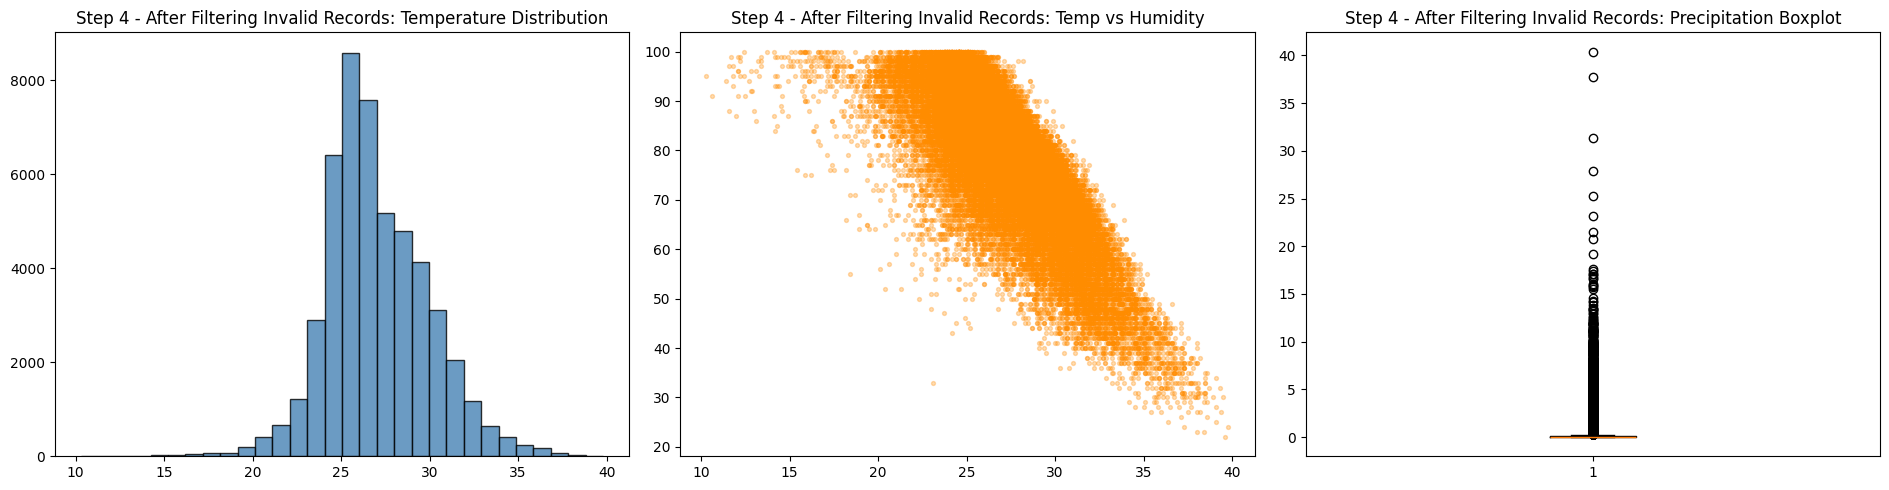

In [7]:
# Step 4: Filter invalid records
filtered_df = df_clean.filter(
    (col("temperature_2m") >= 10) & (col("temperature_2m") <= 50) &
    (col("relative_humidity_2m") >= 0) & (col("relative_humidity_2m") <= 100) &
    (col("precipitation") >= 0) &
    (col("wind_speed_10m") >= 0) &
    (col("city_name") != "")
).cache()
print("Rows after filtering:", filtered_df.count())
eda_matplotlib(filtered_df, "Step 4 - After Filtering Invalid Records")

root
 |-- datetime: timestamp (nullable = true)
 |-- weather_code: integer (nullable = true)
 |-- snow_depth: double (nullable = false)


===== EDA CHECKPOINT: Step 5 - After Type Conversion =====
Rows: 1499309 Columns: 44
Rows with at least one missing value: 0
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|summary|   temperature_2m|relative_humidity_2m|      precipitation|    wind_speed_10m|apparent_temperature|
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|  count|          1499309|             1499309|            1499309|           1499309|             1499309|
|   mean|26.99677558326883|   80.23409670446054|0.27922662532987724| 9.304850496721084|   31.41197861787452|
| stddev|2.927737710275007|  13.595936106168407|  1.043537496437506|6.2760107397191085|  3.6123908704114633|
|    min|             10.0|                20.0|                0.0|               

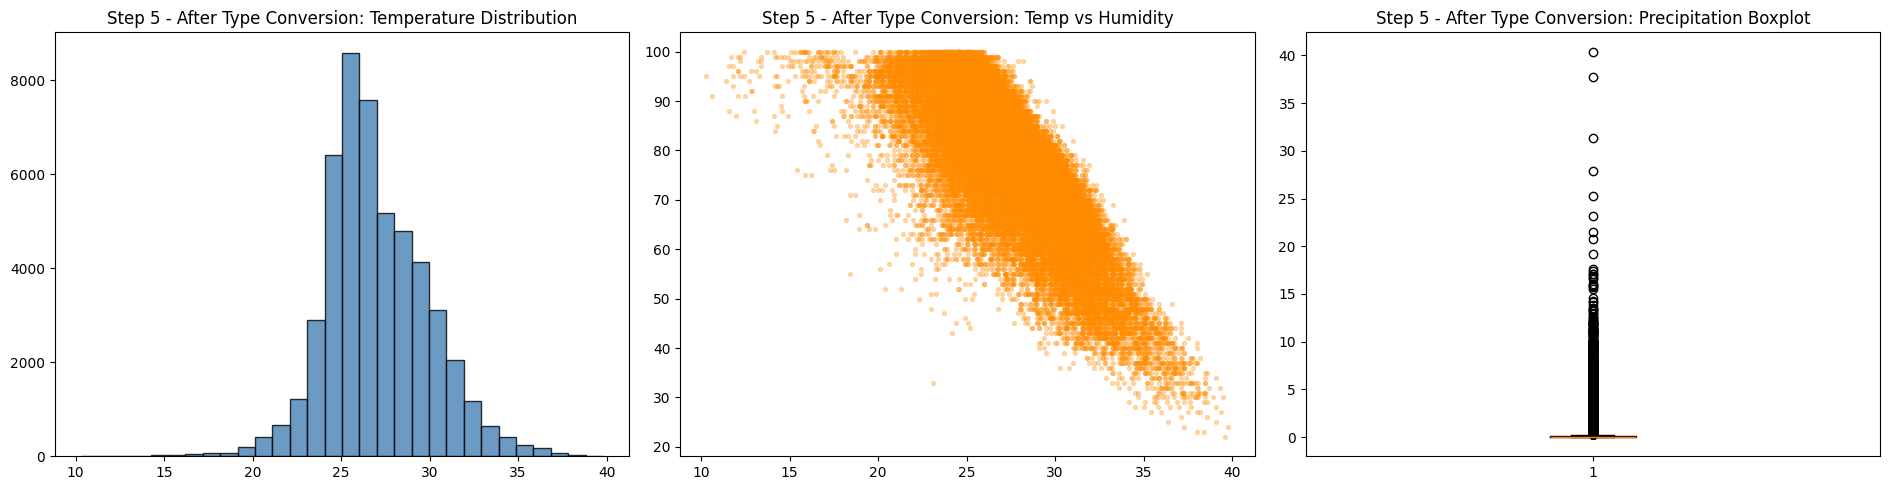

In [8]:
# Step 5: Type conversion
typed_df = (
    filtered_df
    .withColumn("datetime", to_timestamp(col("datetime"), "yyyy-MM-dd HH:mm:ss"))
    .withColumn("weather_code", col("weather_code").cast(IntegerType()))
    .withColumn("snow_depth", col("snow_depth").cast(DoubleType()))
)
typed_df.select("datetime", "weather_code", "snow_depth").printSchema()
eda_matplotlib(typed_df, "Step 5 - After Type Conversion")


===== EDA CHECKPOINT: Step 6 - After Feature Engineering =====
Rows: 1499309 Columns: 49
Rows with at least one missing value: 0
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|summary|   temperature_2m|relative_humidity_2m|      precipitation|    wind_speed_10m|apparent_temperature|
+-------+-----------------+--------------------+-------------------+------------------+--------------------+
|  count|          1499309|             1499309|            1499309|           1499309|             1499309|
|   mean|26.99677558326883|   80.23409670446054|0.27922662532987724| 9.304850496721084|   31.41197861787452|
| stddev|2.927737710275007|  13.595936106168407|  1.043537496437506|6.2760107397191085|  3.6123908704114633|
|    min|             10.0|                20.0|                0.0|               0.0|                 8.9|
|    max|             40.5|               100.0|               77.6|              72.3|                45.6

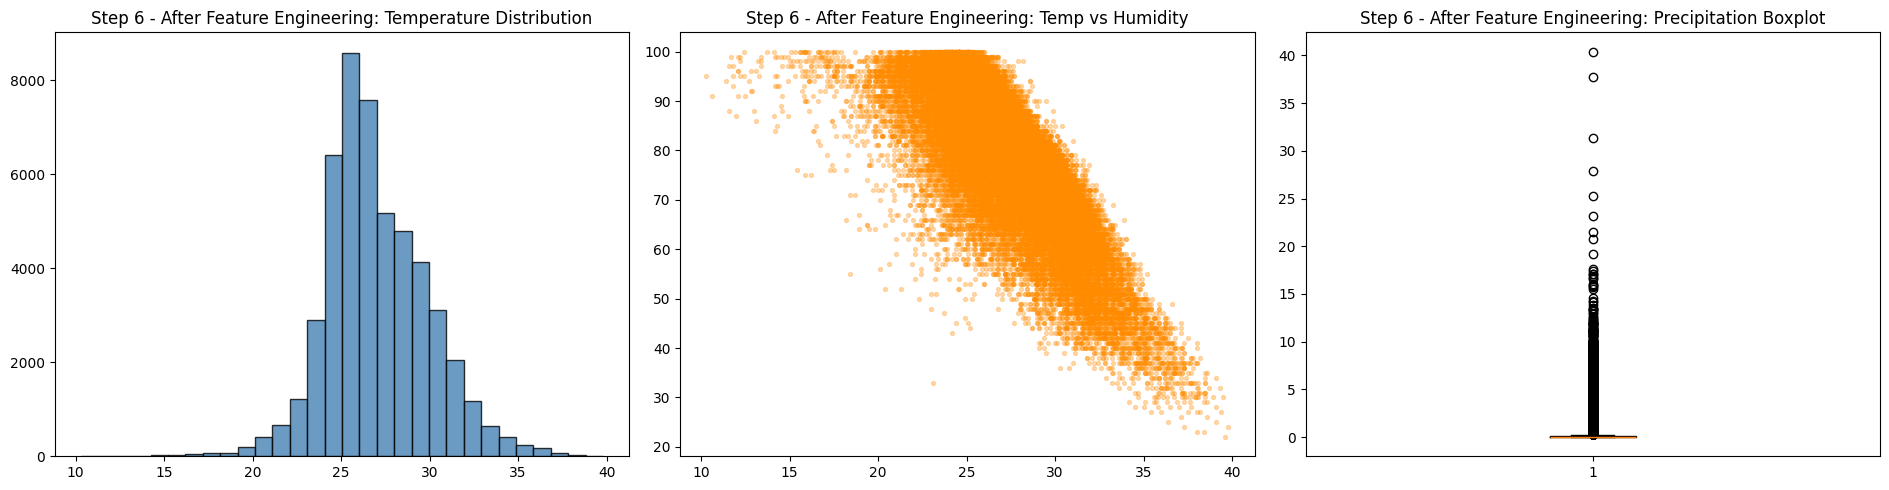

In [9]:
# Step 6: Feature engineering
enriched_df = (
    typed_df
    .withColumn("temperature_f", (col("temperature_2m") * 9 / 5) + 32)
    .withColumn("is_raining", col("rain") > 0)
    .withColumn(
        "heat_category",
        when(col("apparent_temperature") < 26, "Cool")
        .when((col("apparent_temperature") >= 26) & (col("apparent_temperature") < 32), "Comfortable")
        .when((col("apparent_temperature") >= 32) & (col("apparent_temperature") < 38), "Hot")
        .otherwise("Very Hot")
    )
    .withColumn("hour", hour(col("datetime")))
    .withColumn("month", month(col("datetime")))
)
eda_matplotlib(enriched_df, "Step 6 - After Feature Engineering")

Daily summary rows: 62472
Daily rows with missing values: 0
Saved plot: analysis_assets\step7_daily_summary_eda.png


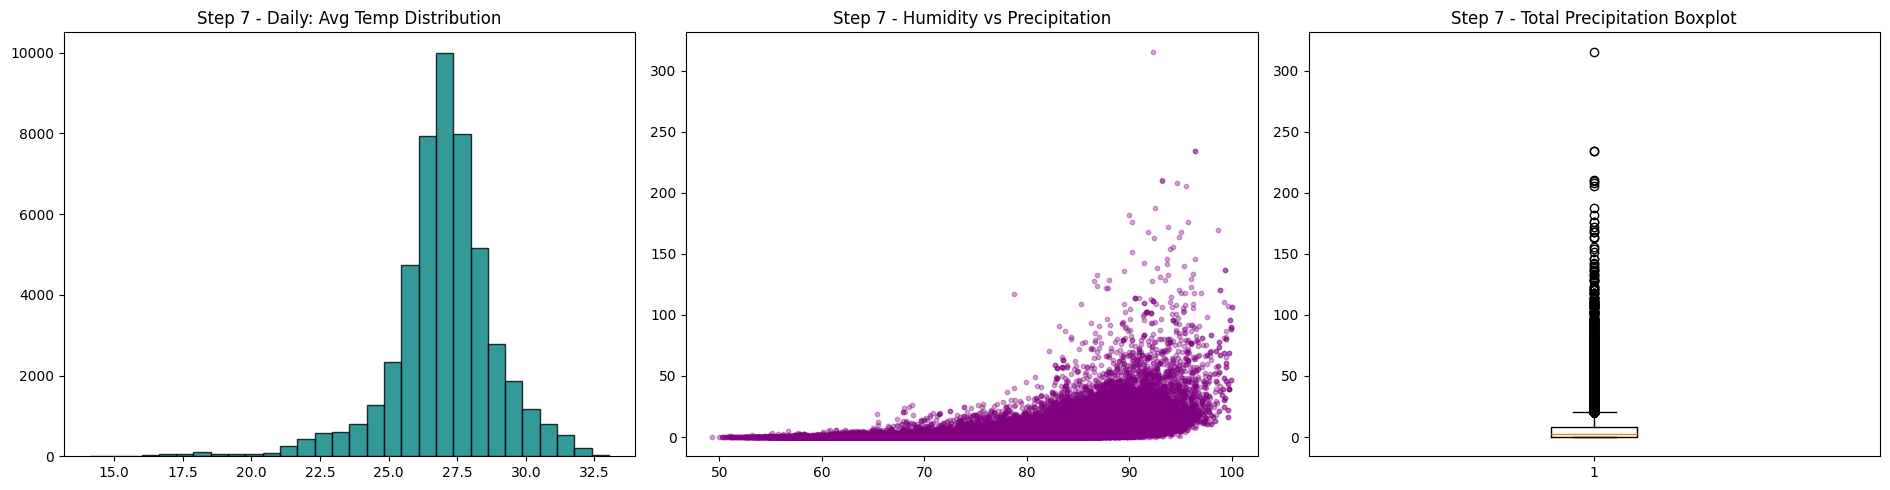

In [10]:
# Step 7: Daily aggregate + EDA
daily_summary = (
    enriched_df.withColumn("date", to_date(col("datetime")))
    .groupBy("city_name", "date")
    .agg(
        spark_round(avg("temperature_2m"), 2).alias("avg_temp_c"),
        spark_round(spark_max("temperature_2m"), 2).alias("max_temp_c"),
        spark_round(spark_min("temperature_2m"), 2).alias("min_temp_c"),
        spark_round(spark_sum("precipitation"), 2).alias("total_precipitation_mm"),
        spark_round(avg("relative_humidity_2m"), 2).alias("avg_humidity_pct"),
        spark_round(spark_max("wind_speed_10m"), 2).alias("max_wind_speed_kmh"),
        spark_sum(col("is_raining").cast("int")).alias("rainy_hours")
    )
)

print("Daily summary rows:", daily_summary.count())
daily_missing_cond = (
    col("city_name").isNull() | col("date").isNull() | col("avg_temp_c").isNull() |
    col("max_temp_c").isNull() | col("min_temp_c").isNull() | col("total_precipitation_mm").isNull() |
    col("avg_humidity_pct").isNull() | col("max_wind_speed_kmh").isNull() | col("rainy_hours").isNull()
)
print("Daily rows with missing values:", daily_summary.filter(daily_missing_cond).count())

daily_pdf = daily_summary.select("avg_temp_c", "total_precipitation_mm", "avg_humidity_pct").dropna().limit(50000).toPandas()
if not daily_pdf.empty:
    fig, ax = plt.subplots(1, 3, figsize=(19, 5))
    ax[0].hist(daily_pdf["avg_temp_c"], bins=30, color="teal", edgecolor="black", alpha=0.8)
    ax[0].set_title("Step 7 - Daily: Avg Temp Distribution")
    ax[1].scatter(daily_pdf["avg_humidity_pct"], daily_pdf["total_precipitation_mm"], s=10, alpha=0.35, color="purple")
    ax[1].set_title("Step 7 - Humidity vs Precipitation")
    ax[2].boxplot(daily_pdf["total_precipitation_mm"], vert=True)
    ax[2].set_title("Step 7 - Total Precipitation Boxplot")
    plt.tight_layout()
    step7_path = os.path.join("analysis_assets", "step7_daily_summary_eda.png")
    fig.savefig(step7_path, dpi=150, bbox_inches="tight")
    print("Saved plot:", step7_path)
    plt.show()

In [11]:
# Step 8: Save cleaned full-dataset outputs (Windows-safe)
output_clean_parquet = "cleaned_weather_full.parquet"
output_daily_parquet = "daily_summary_full.parquet"
output_clean_csv_dir = "cleaned_weather_full_csv"
output_daily_csv_dir = "daily_summary_full_csv"
output_clean_csv_file = "cleaned_weather_full.csv"
output_daily_csv_file = "daily_summary_full.csv"

cleaned_project_df = enriched_df.select(
    "city_name", "datetime", "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "wind_speed_10m", "pressure_msl", "cloud_cover",
    "temperature_f", "is_raining", "heat_category", "hour", "month"
)

try:
    cleaned_project_df.write.mode("overwrite").option("header", True).csv(output_clean_csv_dir)
    daily_summary.write.mode("overwrite").option("header", True).csv(output_daily_csv_dir)
    print("Spark CSV export: SUCCESS")
except Exception as e:
    print("Spark CSV export failed. Using pandas fallback.")
    print("Reason:", str(e)[:250], "...")
    cleaned_project_df.toPandas().to_csv(output_clean_csv_file, index=False)
    daily_summary.toPandas().to_csv(output_daily_csv_file, index=False)
    print("Pandas CSV export: SUCCESS")

try:
    cleaned_project_df.write.mode("overwrite").parquet(output_clean_parquet)
    daily_summary.write.mode("overwrite").parquet(output_daily_parquet)
    print("Spark Parquet export: SUCCESS")
except Exception as e:
    print("Spark Parquet export skipped (likely winutils/HADOOP_HOME issue).")
    print("Reason:", str(e)[:250], "...")

Spark CSV export failed. Using pandas fallback.
Reason: An error occurred while calling o3567.csv.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems ...
Pandas CSV export: SUCCESS
Spark Parquet export skipped (likely winutils/HADOOP_HOME issue).
Reason: An error occurred while calling o3583.parquet.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProb ...


Before rows: 1499328
After rows: 1499309
Before rows with missing: 269000
After rows with missing: 0
Saved plot: analysis_assets\step9_before_vs_after_comparison.png


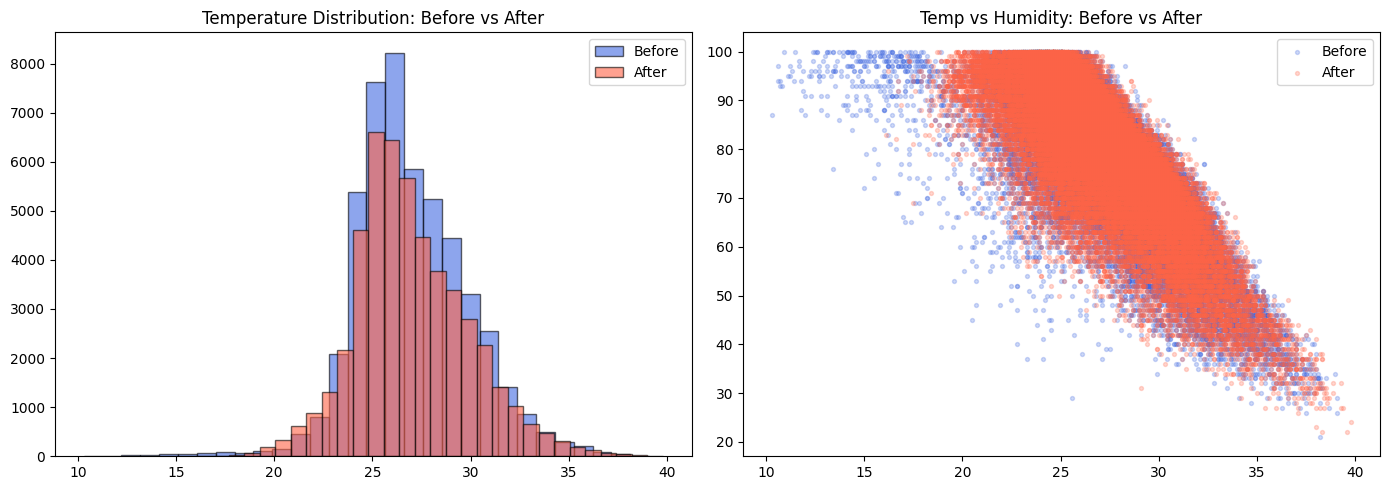

In [12]:
# Step 9: Before vs After EDA comparison
print("Before rows:", df.count())
print("After rows:", cleaned_project_df.count())
print("Before rows with missing:", df.filter(reduce(lambda a,b: a|b, [col(c).isNull() | (isnan(col(c)) if t in ('double','float') else col(c).isNull()) for c,t in df.dtypes])).count())
print("After rows with missing:", cleaned_project_df.filter(reduce(lambda a,b: a|b, [col(c).isNull() | (isnan(col(c)) if t in ('double','float') else col(c).isNull()) for c,t in cleaned_project_df.dtypes])).count())

before_pdf = df.select("temperature_2m", "relative_humidity_2m").dropna().sample(False, 0.06, 42).limit(50000).toPandas()
after_pdf = cleaned_project_df.select("temperature_2m", "relative_humidity_2m").dropna().sample(False, 0.06, 42).limit(50000).toPandas()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(before_pdf["temperature_2m"], bins=30, alpha=0.6, label="Before", color="royalblue", edgecolor="black")
ax[0].hist(after_pdf["temperature_2m"], bins=30, alpha=0.6, label="After", color="tomato", edgecolor="black")
ax[0].set_title("Temperature Distribution: Before vs After")
ax[0].legend()

ax[1].scatter(before_pdf["temperature_2m"], before_pdf["relative_humidity_2m"], s=8, alpha=0.25, label="Before", color="royalblue")
ax[1].scatter(after_pdf["temperature_2m"], after_pdf["relative_humidity_2m"], s=8, alpha=0.25, label="After", color="tomato")
ax[1].set_title("Temp vs Humidity: Before vs After")
ax[1].legend()
plt.tight_layout()
step9_path = os.path.join("analysis_assets", "step9_before_vs_after_comparison.png")
fig.savefig(step9_path, dpi=150, bbox_inches="tight")
print("Saved plot:", step9_path)
plt.show()

In [13]:
# Step 10: Build hourly city heat-risk features from 2024 heat index
from pyspark.sql import functions as F

start_2024 = F.to_timestamp(F.lit("2024-01-01 00:00:00"))
start_2025 = F.to_timestamp(F.lit("2025-01-01 00:00:00"))

hourly_2024 = (
    cleaned_project_df
    .filter((F.col("datetime") >= start_2024) & (F.col("datetime") < start_2025))
    .filter(F.col("city_name").isNotNull() & (F.col("city_name") != ""))
    .filter(F.col("temperature_2m").isNotNull() & F.col("relative_humidity_2m").isNotNull())
)

# NOAA-style heat index in Fahrenheit, then converted back to Celsius.
heat_hourly_2024 = (
    hourly_2024
    .withColumn("temp_f", (F.col("temperature_2m") * 9.0 / 5.0) + 32.0)
    .withColumn("rh", F.col("relative_humidity_2m"))
    .withColumn(
        "hi_simple_f",
        0.5 * (
            F.col("temp_f") + 61.0 + ((F.col("temp_f") - 68.0) * 1.2) + (F.col("rh") * 0.094)
        )
    )
    .withColumn(
        "hi_rothfusz_f",
        F.expr(
            "-42.379 + 2.04901523*temp_f + 10.14333127*rh - 0.22475541*temp_f*rh "
            "+ -0.00683783*temp_f*temp_f + -0.05481717*rh*rh "
            "+ 0.00122874*temp_f*temp_f*rh + 0.00085282*temp_f*rh*rh "
            "+ -0.00000199*temp_f*temp_f*rh*rh"
        )
    )
    .withColumn(
        "hi_adjustment_f",
        F.when(
            (F.col("rh") < 13) & (F.col("temp_f") >= 80) & (F.col("temp_f") <= 112),
            ((13 - F.col("rh")) / 4.0) * F.sqrt((17 - F.abs(F.col("temp_f") - 95.0)) / 17.0)
        )
        .when(
            (F.col("rh") > 85) & (F.col("temp_f") >= 80) & (F.col("temp_f") <= 87),
            ((F.col("rh") - 85.0) / 10.0) * ((87.0 - F.col("temp_f")) / 5.0)
        )
        .otherwise(F.lit(0.0))
    )
    .withColumn(
        "heat_index_f",
        F.when(
            (F.col("temp_f") >= 80) & (F.col("rh") >= 40),
            F.col("hi_rothfusz_f") - F.col("hi_adjustment_f")
        ).otherwise(F.col("hi_simple_f"))
    )
    .withColumn("heat_index_c", F.round((F.col("heat_index_f") - 32.0) * 5.0 / 9.0, 2))
    .withColumn(
        "heat_index_level",
        F.when(F.col("heat_index_c") < 27, "Low")
        .when((F.col("heat_index_c") >= 27) & (F.col("heat_index_c") <= 32), "Moderate")
        .when((F.col("heat_index_c") > 32) & (F.col("heat_index_c") < 42), "High")
        .otherwise("Extreme")
    )
    .withColumn("is_dangerous", F.col("heat_index_c") >= 42)
    .withColumn(
        "hourly_heat_risk_level",
        F.when(F.col("heat_index_c") < 27, "Low")
        .when((F.col("heat_index_c") >= 27) & (F.col("heat_index_c") <= 32), "Moderate")
        .when((F.col("heat_index_c") > 32) & (F.col("heat_index_c") < 42), "High")
        .otherwise("Extreme")
    )
    .withColumn(
        "hourly_heat_risk_score",
        F.when(F.col("hourly_heat_risk_level") == "Low", F.lit(1))
        .when(F.col("hourly_heat_risk_level") == "Moderate", F.lit(2))
        .when(F.col("hourly_heat_risk_level") == "High", F.lit(3))
        .otherwise(F.lit(4))
    )
)

print("2024 hourly rows:", heat_hourly_2024.count())
heat_hourly_2024.select("city_name", "datetime", "temperature_2m", "relative_humidity_2m", "heat_index_c", "heat_index_level").show(10, truncate=False)

# Objective-focused row-level export (heat index features by hour).
heat_hourly_2024_export = heat_hourly_2024.select(
    "city_name", "datetime", "temperature_2m", "relative_humidity_2m",
    "heat_index_c", "heat_index_level", "hourly_heat_risk_level",
    "hourly_heat_risk_score", "is_dangerous"
)

heat_hourly_csv_dir = "hourly_heat_index_2024_full_csv"
heat_hourly_csv_file = "hourly_heat_index_2024_full.csv"
heat_hourly_parquet_dir = "hourly_heat_index_2024_full.parquet"

try:
    heat_hourly_2024_export.write.mode("overwrite").option("header", True).csv(heat_hourly_csv_dir)
    print(f"Spark CSV export: SUCCESS -> {heat_hourly_csv_dir}")
except Exception as e:
    print("Spark CSV export failed. Using pandas fallback.")
    print("Reason:", str(e)[:250], "...")
    heat_hourly_2024_export.toPandas().to_csv(heat_hourly_csv_file, index=False)
    print(f"Pandas CSV export: SUCCESS -> {heat_hourly_csv_file}")

try:
    heat_hourly_2024_export.write.mode("overwrite").parquet(heat_hourly_parquet_dir)
    print(f"Spark Parquet export: SUCCESS -> {heat_hourly_parquet_dir}")
except Exception as e:
    print("Spark Parquet export skipped (likely winutils/HADOOP_HOME issue).")
    print("Reason:", str(e)[:250], "...")

2024 hourly rows: 1203390
+---------+-------------------+--------------+--------------------+------------+----------------+
|city_name|datetime           |temperature_2m|relative_humidity_2m|heat_index_c|heat_index_level|
+---------+-------------------+--------------+--------------------+------------+----------------+
|Bayugan  |2024-01-01 00:00:00|24.7          |94.0                |25.68       |Low             |
|Bayugan  |2024-01-01 01:00:00|25.6          |90.0                |26.57       |Low             |
|Bayugan  |2024-01-01 02:00:00|25.0          |91.0                |25.93       |Low             |
|Bayugan  |2024-01-01 03:00:00|24.3          |94.0                |25.24       |Low             |
|Bayugan  |2024-01-01 04:00:00|24.3          |94.0                |25.24       |Low             |
|Bayugan  |2024-01-01 05:00:00|24.0          |97.0                |24.99       |Low             |
|Bayugan  |2024-01-01 06:00:00|23.9          |98.0                |24.9        |Low         

Cities assessed: 137
+----------------+----------------+--------------------+------------------+---------------------+---------------------+-------------------+---------------------------------+---------------+
|city_name       |total_hours_2024|dangerous_hours_2024|extreme_hours_2024|avg_heat_index_c_2024|max_heat_index_c_2024|dangerous_hours_pct|max_consecutive_danger_hours_2024|heat_risk_level|
+----------------+----------------+--------------------+------------------+---------------------+---------------------+-------------------+---------------------------------+---------------+
|San Jose        |8784            |81                  |81                |29.29                |45.0                 |0.92               |6                                |Extreme        |
|Dagupan         |8784            |81                  |81                |29.17                |45.31                |0.92               |5                                |Extreme        |
|Laoag           |8784       

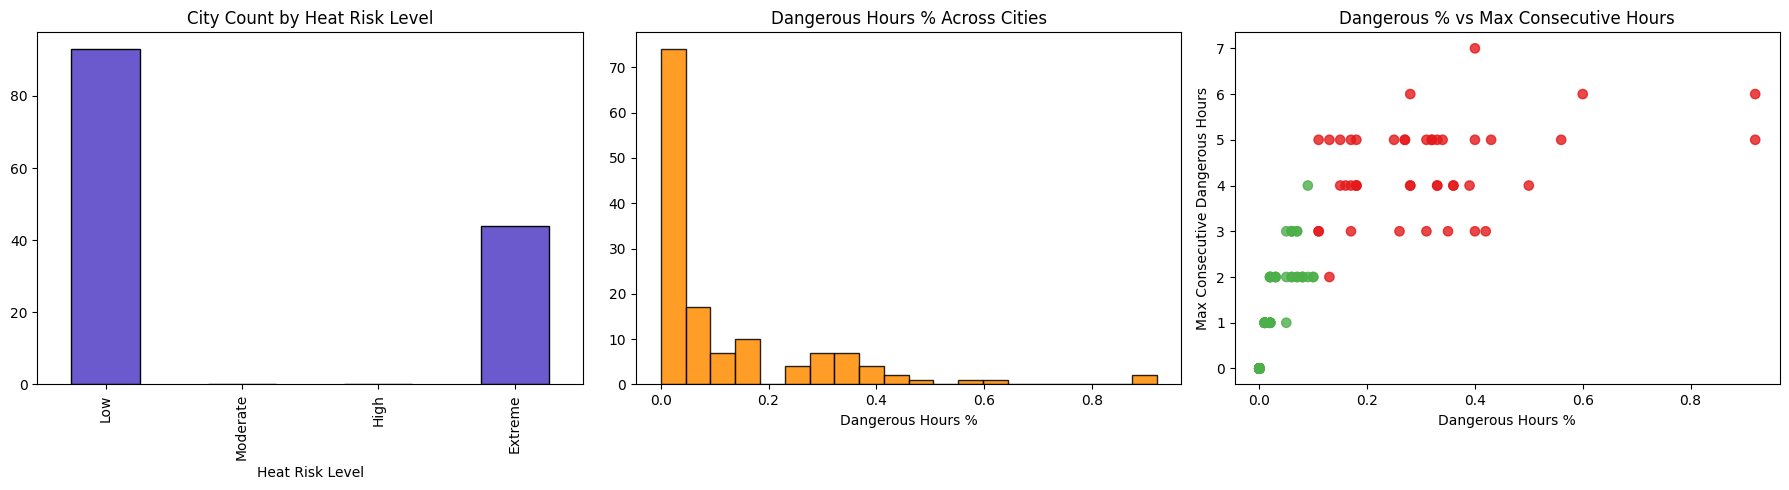

In [14]:
# Step 11: City assessed summary + EDA (display only, no exports)
from pyspark.sql.window import Window

city_exposure_2024 = (
    heat_hourly_2024
    .groupBy("city_name")
    .agg(
        F.count("*").alias("total_hours_2024"),
        F.sum(F.col("is_dangerous").cast("int")).alias("dangerous_hours_2024"),
        F.sum((F.col("hourly_heat_risk_level") == "Extreme").cast("int")).alias("extreme_hours_2024"),
        F.round(F.avg("heat_index_c"), 2).alias("avg_heat_index_c_2024"),
        F.round(F.max("heat_index_c"), 2).alias("max_heat_index_c_2024")
    )
    .withColumn(
        "dangerous_hours_pct",
        F.round((F.col("dangerous_hours_2024") / F.col("total_hours_2024")) * 100, 2)
    )
)

danger_only = heat_hourly_2024.filter(F.col("is_dangerous"))
w_city_time = Window.partitionBy("city_name").orderBy("datetime")

danger_streaks = (
    danger_only
    .withColumn("prev_dt", F.lag("datetime").over(w_city_time))
    .withColumn(
        "new_streak",
        F.when(
            F.col("prev_dt").isNull() |
            ((F.unix_timestamp("datetime") - F.unix_timestamp("prev_dt")) != 3600),
            1
        ).otherwise(0)
    )
    .withColumn("streak_id", F.sum("new_streak").over(w_city_time))
    .groupBy("city_name", "streak_id")
    .agg(F.count("*").alias("streak_hours"))
)

max_streak_2024 = danger_streaks.groupBy("city_name").agg(
    F.max("streak_hours").alias("max_consecutive_danger_hours_2024")
)

city_features_2024 = (
    city_exposure_2024
    .join(max_streak_2024, on="city_name", how="left")
    .fillna({"max_consecutive_danger_hours_2024": 0})
    .withColumn(
        "heat_risk_level",
        F.when(
            (F.col("dangerous_hours_pct") >= 20) |
            (F.col("max_consecutive_danger_hours_2024") >= 24) |
            (F.col("extreme_hours_2024") >= 10),
            "Extreme"
        )
        .when(
            (F.col("dangerous_hours_pct") >= 10) |
            (F.col("max_consecutive_danger_hours_2024") >= 12),
            "High"
        )
        .when(
            (F.col("dangerous_hours_pct") >= 3) |
            (F.col("max_consecutive_danger_hours_2024") >= 6),
            "Moderate"
        )
        .otherwise("Low")
    )
    .orderBy(F.desc("dangerous_hours_pct"), F.desc("max_consecutive_danger_hours_2024"))
)

print("Cities assessed:", city_features_2024.count())
city_features_2024.show(30, truncate=False)

city_pdf = city_features_2024.select(
    "dangerous_hours_pct", "max_consecutive_danger_hours_2024", "avg_heat_index_c_2024", "heat_risk_level"
).toPandas()

if not city_pdf.empty:
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    city_pdf["heat_risk_level"].value_counts().reindex(["Low", "Moderate", "High", "Extreme"], fill_value=0).plot(
        kind="bar", ax=ax[0], color="slateblue", edgecolor="black"
    )
    ax[0].set_title("City Count by Heat Risk Level")
    ax[0].set_xlabel("Heat Risk Level")

    ax[1].hist(city_pdf["dangerous_hours_pct"], bins=20, color="darkorange", edgecolor="black", alpha=0.85)
    ax[1].set_title("Dangerous Hours % Across Cities")
    ax[1].set_xlabel("Dangerous Hours %")

    scatter_colors = city_pdf["heat_risk_level"].map({"Low": "#4daf4a", "Moderate": "#377eb8", "High": "#ff7f00", "Extreme": "#e41a1c"})
    ax[2].scatter(
        city_pdf["dangerous_hours_pct"],
        city_pdf["max_consecutive_danger_hours_2024"],
        c=scatter_colors,
        s=45,
        alpha=0.8
    )
    ax[2].set_title("Dangerous % vs Max Consecutive Hours")
    ax[2].set_xlabel("Dangerous Hours %")
    ax[2].set_ylabel("Max Consecutive Dangerous Hours")

    plt.tight_layout()
    step11_path = os.path.join("analysis_assets", "step11_city_heat_risk_eda.png")
    fig.savefig(step11_path, dpi=150, bbox_inches="tight")
    print("Saved plot:", step11_path)
    plt.show()

In [15]:
# Step 12: Quick check of model-ready columns for clustering input (no clustering yet)
city_features_2024.printSchema()
city_features_2024.select(
    "city_name",
    "dangerous_hours_pct",
    "max_consecutive_danger_hours_2024",
    "avg_heat_index_c_2024",
    "max_heat_index_c_2024",
    "heat_risk_level"
).show(10, truncate=False)

print("Use `city_features_2024` as the input table for the next clustering notebook.")

root
 |-- city_name: string (nullable = false)
 |-- total_hours_2024: long (nullable = false)
 |-- dangerous_hours_2024: long (nullable = true)
 |-- extreme_hours_2024: long (nullable = true)
 |-- avg_heat_index_c_2024: double (nullable = true)
 |-- max_heat_index_c_2024: double (nullable = true)
 |-- dangerous_hours_pct: double (nullable = true)
 |-- max_consecutive_danger_hours_2024: long (nullable = false)
 |-- heat_risk_level: string (nullable = false)

+----------------+-------------------+---------------------------------+---------------------+---------------------+---------------+
|city_name       |dangerous_hours_pct|max_consecutive_danger_hours_2024|avg_heat_index_c_2024|max_heat_index_c_2024|heat_risk_level|
+----------------+-------------------+---------------------------------+---------------------+---------------------+---------------+
|San Jose        |0.92               |6                                |29.29                |45.0                 |Extreme        |
|Dagup